# MIVA-KNIGHT — Pipeline C: RAVDESS Standalone Audio Emotion Training
## Supervisor-Mandated Replan | Audio-Only Supervised Contrastive Learning

---

### What this notebook does and why

**The problem with original Month 2:**
RAVDESS audio was trained jointly with COCO images in one InfoNCE loss.
COCO and RAVDESS share NO genuine cross-modal ground truth.
The synthetic captions (`"A person expressing happy emotion"`) have no real
correspondence to the audio — InfoNCE was pushing semantically valid pairs
apart as negatives, corrupting the 512-d space geometry.
Result: Month 3 SupCon destroyed the space → audio accuracy fell 5/8 → 2/8.

**The fix — Pipeline C:**
Train `AudioProjection` on RAVDESS **alone**, using Supervised Contrastive loss
(SupCon, Khosla et al. 2020). No images. No COCO. No synthetic captions.
The only signal: same-emotion clips pulled together, different-emotion pushed apart.

**What also gets fixed here — the wav2vec_dim bug:**
The original Month 2 cached RAVDESS embeddings at 512d.
Wav2Vec 2.0 base actually outputs **768d** hidden states.
Something truncated during the original extraction.
This notebook re-extracts directly from raw `.wav` files at the correct **768d**,
giving `AudioProjection(768 → 512)` full representational capacity.

---

### Architecture

```
RAVDESS .wav file
        │
        ▼
  Wav2Vec 2.0 (frozen)
  facebook/wav2vec2-base-960h
        │  768d hidden states
        │  mean-pooled over time
        ▼
  AudioProjection  (TRAINS)
  Linear(768→768) → GELU → LayerNorm → Linear(768→512) → LayerNorm → L2-norm
        │
        ▼
  512d emotion embedding  ê_audio ∈ ℝ⁵¹²

Loss: Supervised Contrastive (SupCon)
  Same emotion  → pulled together  (positive pairs)
  Diff emotion  → pushed apart     (negative pairs)
  No text. No images. Pure audio emotion clustering.
```

---

### Outputs

| File | Description | Used by |
|---|---|---|
| `audio_projection.pth` | Trained AudioProjection weights | `pipeline.py`, `domain_config.py` |
| `emotion_centroids.pt` | 8 × 512d mean centroids per emotion | Inference: detect user emotion |
| `ravdess_embeddings_768d.pt` | Fresh 768d Wav2Vec cache | Reusable for future runs |
| `config.json` | Hyperparameters + final metrics | Reproducibility |

---

### 4-Pipeline context

| Pipeline | Dataset | Status |
|---|---|---|
| A — COCO image-text | COCO val2017 | ✅ Month 1 complete |
| B — ROCO medical | ROCO radiology | ✅ Month 4 complete |
| **C — RAVDESS audio (this notebook)** | **RAVDESS 1,440 clips** | 🔄 **Now** |
| D — CREMA-D audio-visual | CREMA-D 7,442 clips | ⏳ Month 6 |

**Run every cell top to bottom. Do not skip.**


## Cell 1: Install Dependencies

| Package | Purpose | New vs Month 2? |
|---|---|---|
| `transformers` | Wav2Vec 2.0 model + processor | No |
| `torch` / `torchaudio` | Neural nets, audio I/O | `torchaudio` now actively used |
| `librosa` | Audio loading fallback (16kHz mono) | No |
| `soundfile` | Low-level .wav reading (librosa backend) | No |
| `numpy`, `matplotlib` | Numerics, training curves | No |
| `tqdm` | Progress bars | No |

**Not installed:** `faiss-cpu`, `datasets`, `gtts`, `groq`, `scispacy` — none needed for audio-only training.


In [2]:
!pip install -q transformers torchaudio librosa soundfile
print("\u2713 Packages installed")


✓ Packages installed


## Cell 2: Imports & Reproducibility

Seed 42 used throughout all MIVA-KNIGHT notebooks for bit-identical reproducibility.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import json, os, pickle, time, warnings
from tqdm.auto import tqdm
from collections import defaultdict, Counter

import torchaudio
from transformers import Wav2Vec2Model, Wav2Vec2Processor

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {device}")
if device == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")
print("\n\u2713 All imports complete — Pipeline C (RAVDESS audio only)")


Device  : cpu
PyTorch : 2.10.0+cpu

✓ All imports complete — Pipeline C (RAVDESS audio only)


## Cell 3: Mount Drive & Set Paths

### Critical path notes
- Trailing space in project folder name: `" Oluwakayode Soyinka IT 581 Project "` — preserved exactly
- PyTorch 2.6 patch applied before any `torch.load()` call
- Output goes to `miva_knight_pipelineC/` — separate folder, does not overwrite Month 2 weights

### RAVDESS folder structure on Drive
```
Data/RAVDESS Emotional speech audio/
├── Actor_01/
│   ├── 03-01-01-01-01-01-01.wav
│   ├── 03-01-02-01-01-01-01.wav
│   └── ...
├── Actor_02/
│   └── ...
└── Actor_24/
    └── ...
```

### RAVDESS filename encoding (digit positions, 1-indexed)
```
03 - 01 - 05 - 01 - 02 - 01 - 12.wav
│    │    │    │    │    │    └── Actor ID (01-24)
│    │    │    │    │    └── Repetition (01=1st, 02=2nd)
│    │    │    │    └── Statement (01="Kids are.." 02="Dogs are..")
│    │    │    └── Intensity (01=normal, 02=strong)
│    │    └── Emotion code (01=neutral 02=calm 03=happy 04=sad
│    │                      05=angry 06=fearful 07=disgust 08=surprised)
│    └── Vocal channel (01=speech, 02=song)
└── Modality (01=AV, 02=video, 03=audio-only)
```
We use audio-only files (modality=03) with speech channel (vocal=01).


In [4]:
from google.colab import drive
drive.mount('/content/drive')

# ── PyTorch 2.6 patch — MUST run before any torch.load() ──────────────────
import torch as _torch
_orig_load = _torch.load
def _patched_load(f, *args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_load(f, *args, **kwargs)
_torch.load = _patched_load
print("\u2713 PyTorch 2.6 patch applied")

# ── Auto-detect project base ───────────────────────────────────────────────
POSSIBLE_BASES = [
    '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project ',
    '/content/drive/MyDrive/Oluwakayode Soyinka IT 581 Project',
    '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project',
]
shortcut_root = '/content/drive/.shortcut-targets-by-id'
if os.path.exists(shortcut_root):
    for sid in os.listdir(shortcut_root):
        sp = os.path.join(shortcut_root, sid)
        if os.path.isdir(sp):
            for folder in os.listdir(sp):
                if 'soyinka' in folder.lower() or '581' in folder.lower():
                    POSSIBLE_BASES.append(os.path.join(sp, folder))

PROJECT_BASE = None
for path in POSSIBLE_BASES:
    if os.path.exists(path) and os.path.exists(os.path.join(path, 'models')):
        PROJECT_BASE = path
        break

if PROJECT_BASE is None:
    raise RuntimeError("Project folder not found. Check Drive is mounted.")

print(f"\u2713 Project base: {PROJECT_BASE}")

# ── Paths ──────────────────────────────────────────────────────────────────
RAVDESS_DIR   = os.path.join(PROJECT_BASE, 'Data', 'RAVDESS Emotional speech audio')
AUDIO_CACHE   = os.path.join(PROJECT_BASE, 'Data', 'audio_embeddings_cache')
CACHE_768_FILE = os.path.join(AUDIO_CACHE, 'ravdess_embeddings_768d.pt')  # NEW: correct dim
PIPELINE_C_DIR = os.path.join(PROJECT_BASE, 'models', 'miva_knight_pipelineC')
CHECKPOINT    = os.path.join(PIPELINE_C_DIR, 'checkpoint_pipelineC_latest.pth')

# Also know where Month 1 KG lives (needed for centroid save metadata)
M2_DIR        = os.path.join(PROJECT_BASE, 'models', 'miva_knight_month2_rebuilt')

os.makedirs(PIPELINE_C_DIR, exist_ok=True)
os.makedirs(AUDIO_CACHE,    exist_ok=True)

# ── Training config ────────────────────────────────────────────────────────
EMBED_DIM    = 512
WAV2VEC_DIM  = 768    # Correct Wav2Vec 2.0 base output dim — NOT 512
NUM_EPOCHS   = 30     # More epochs: 1,440 samples is small, needs more passes
BATCH_SIZE   = 16
TEMPERATURE  = 0.07

# ── Verify RAVDESS directory ───────────────────────────────────────────────
assert os.path.exists(RAVDESS_DIR), f"RAVDESS not found at: {RAVDESS_DIR}"
actor_dirs = [d for d in os.listdir(RAVDESS_DIR) if d.startswith('Actor_')]
wav_count  = sum(
    len([f for f in os.listdir(os.path.join(RAVDESS_DIR, a)) if f.endswith('.wav')])
    for a in actor_dirs
)
print(f"\u2713 RAVDESS: {len(actor_dirs)} actors, {wav_count} .wav files found")
print(f"\u2713 New 768d cache: {CACHE_768_FILE}")
print(f"\u2713 Output dir: {PIPELINE_C_DIR}")


Mounted at /content/drive
✓ PyTorch 2.6 patch applied
✓ Project base: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project 
✓ RAVDESS: 24 actors, 1440 .wav files found
✓ New 768d cache: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/audio_embeddings_cache/ravdess_embeddings_768d.pt
✓ Output dir: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineC


In [5]:
import os
CREMA_DIR = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/CREMA-D'
for folder in os.listdir(CREMA_DIR):
    path = os.path.join(CREMA_DIR, folder)
    if os.path.isdir(path):
        files = os.listdir(path)
        print(f"{folder}: {len(files)} files | sample: {files[0]}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/CREMA-D'

## Cell 4: AudioProjection Architecture

### The wav2vec_dim bug — explained and fixed

**Original Month 2 bug:**
The old RAVDESS cache stored embeddings at 512d.
`AudioProjection` was therefore initialized as `AudioProjection(wav2vec_dim=512)` —
a near-identity 512→512 map with very limited capacity.
SupCon in Month 3 had almost nothing to work with, so gradients dominated the text-image
geometry trained by COCO, causing the 5/8→2/8 regression.

**Fix in Pipeline C:**
We re-extract from raw `.wav` files through Wav2Vec 2.0 base, which outputs **768d**.
`AudioProjection(768→512)` now has a meaningful projection to learn:
compressing 768-dimensional phonetic/prosodic features into a 512-d emotion-specific space.

### Architecture: 2-layer MLP (matches TextProjection design)

$$f_\theta(x) = \text{L2-norm}(\text{LN}_{512}(W_2 \cdot \text{GELU}(\text{LN}_{768}(W_1 x))))$$

| Layer | Shape | Notes |
|---|---|---|
| Linear | 768 → 768 | Initial feature mixing |
| GELU | — | Smooth non-linearity |
| LayerNorm | 768 | Stabilizes hidden activations |
| Linear | 768 → 512 | Projects to shared embedding dim |
| LayerNorm | 512 | Stabilizes output |
| L2-norm | 512 | Projects onto unit hypersphere |


In [4]:
EMBED_DIM   = 512
WAV2VEC_DIM = 768   # Confirmed correct Wav2Vec 2.0 base output dim

class AudioProjection(nn.Module):
    """
    Projects Wav2Vec 2.0 768d mean-pooled hidden states into shared 512d space.

    Key fix vs original Month 2:
      Old: wav2vec_dim=512 (cached at wrong dim — near-identity map)
      New: wav2vec_dim=768 (correct — full projection with learning capacity)

    Architecture matches TextProjection (same pattern throughout MIVA-KNIGHT):
      Linear(768→768) → GELU → LayerNorm(768) → Linear(768→512) → LayerNorm(512) → L2-norm
    """
    def __init__(self, wav2vec_dim=WAV2VEC_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(wav2vec_dim, wav2vec_dim),
            nn.GELU(),
            nn.LayerNorm(wav2vec_dim),
            nn.Linear(wav2vec_dim, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, wav2vec_emb):
        """wav2vec_emb: [B, 768] mean-pooled Wav2Vec hidden states → [B, 512] L2-normalized."""
        return F.normalize(self.norm(self.proj(wav2vec_emb)), p=2, dim=1)

# Parameter count
_ap   = AudioProjection()
n_par = sum(p.numel() for p in _ap.parameters())
print(f"\u2713 AudioProjection defined")
print(f"  Input dim  : {WAV2VEC_DIM}d  (Wav2Vec 2.0 base — correct)")
print(f"  Output dim : {EMBED_DIM}d   (shared embedding space)")
print(f"  Parameters : {n_par:,} trainable")
del _ap


✓ AudioProjection defined
  Input dim  : 768d  (Wav2Vec 2.0 base — correct)
  Output dim : 512d   (shared embedding space)
  Parameters : 986,880 trainable


## Cell 5: Wav2Vec 2.0 Encoder (Frozen)

### Why freeze Wav2Vec?

Wav2Vec 2.0 has 94M parameters trained on 960 hours of LibriSpeech speech.
It already extracts rich phonetic and prosodic features from raw audio.
We only need to train `AudioProjection` — the small head that maps those
features into the 512-d emotion space.

Freezing Wav2Vec:
- Saves VRAM (critical on Colab free tier)
- Prevents catastrophic forgetting of learned speech representations
- Makes training faster (~10× fewer gradient computations)

### Audio preprocessing requirements

Wav2Vec 2.0 base requires:
- **Sample rate:** 16,000 Hz (RAVDESS files are already 16kHz ✓)
- **Channels:** Mono (RAVDESS is mono ✓)
- **Format:** Raw float32 waveform (no MFCC or spectrogram)
- **Input:** `input_values` tensor of shape `[1, T]` where T = number of samples

### Mean pooling over time

Wav2Vec outputs hidden states at every time step: `[1, T', 768]`.
We mean-pool over T' to get a fixed-size `[1, 768]` sentence-level representation.
This captures the average emotional quality across the full utterance.


In [5]:
class Wav2VecEncoder(nn.Module):
    """
    Frozen Wav2Vec 2.0 backbone.
    Produces 768d mean-pooled frame-level representations.
    AudioProjection trains on top — Wav2Vec weights never update.
    """
    def __init__(self, model_name='facebook/wav2vec2-base-960h'):
        super().__init__()
        print(f"  Loading {model_name}...")
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model     = Wav2Vec2Model.from_pretrained(model_name)
        for p in self.model.parameters():
            p.requires_grad = False
        self.model.eval()
        print(f"  \u2713 Wav2Vec 2.0 frozen (94M params, 0 trainable)")
        print(f"  \u2713 Output dim: 768d (base model)")

    @torch.no_grad()
    def encode_file(self, wav_path: str) -> torch.Tensor:
        """
        Load .wav file → run Wav2Vec → mean-pool → [1, 768].
        Handles resampling to 16kHz if needed.
        """
        waveform, sr = torchaudio.load(wav_path)
        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)
        # Convert to mono if stereo
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        waveform = waveform.squeeze(0).numpy()  # [T]

        inputs = self.processor(
            waveform,
            sampling_rate=16000,
            return_tensors='pt',
            padding=True
        )
        input_values = inputs.input_values.to(
            next(self.model.parameters()).device)

        outputs = self.model(input_values)
        # hidden_states: [1, T', 768] → mean over T' → [1, 768]
        hidden = outputs.last_hidden_state.mean(dim=1)
        return hidden.cpu()   # [1, 768]

print("\u2713 Wav2VecEncoder defined")


✓ Wav2VecEncoder defined


## Cell 6: Extract & Cache RAVDESS Embeddings at 768d

### Why cache instead of encoding on-the-fly?

Each Wav2Vec encoding of a 3-second clip takes ~0.3s on GPU.
1,440 clips × 30 epochs = 43,200 Wav2Vec calls = **~3.6 hours** just on encoding.

By caching all 1,440 embeddings once (~2 minutes), each training epoch
reads pre-computed tensors from memory — **~240× faster**.

### Filename parsing — emotion extraction

RAVDESS filenames encode emotion in **digit position 3** (1-indexed):
```
03-01-05-01-02-01-12.wav
         ↑
         Emotion code: 05 = angry
```

Emotion code → label mapping:
```python
{1:'neutral', 2:'calm', 3:'happy', 4:'sad',
 5:'angry',   6:'fearful', 7:'disgust', 8:'surprised'}
```

### Cache format (new 768d)

```python
{
  '03-01-05-01-02-01-12.wav': {
      'embedding': tensor([768]),   # ← 768d, NOT 512d
      'emotion'  : 'angry',
      'actor_id' : 12,
      'intensity': 'strong',
  },
  ...
}
```

### Resume logic

If `ravdess_embeddings_768d.pt` already exists on Drive, this cell loads it
instead of re-extracting — safe to re-run after a Colab disconnect.


In [6]:
EMOTION_MAP = {
    1: 'neutral', 2: 'calm',     3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful',  7: 'disgust',  8: 'surprised'
}
EMOTIONS_8 = ['neutral', 'calm', 'happy', 'sad',
               'angry',   'fearful', 'disgust', 'surprised']

def parse_ravdess_filename(filename):
    """
    Parse RAVDESS filename → dict with emotion, actor_id, intensity.
    Returns None for malformed filenames.

    Format: 03-01-EMOTION-INTENSITY-STATEMENT-REPETITION-ACTOR.wav
    Positions (1-indexed): modality-channel-emotion-intensity-statement-rep-actor
    """
    name = os.path.splitext(filename)[0]
    parts = name.split('-')
    if len(parts) != 7:
        return None
    try:
        modality   = int(parts[0])
        channel    = int(parts[1])
        emotion_id = int(parts[2])
        intensity  = int(parts[3])
        actor_id   = int(parts[6])
    except ValueError:
        return None

    # Only audio-only (modality=03) speech (channel=01) files
    if modality != 3 or channel != 1:
        return None
    if emotion_id not in EMOTION_MAP:
        return None

    return {
        'emotion'  : EMOTION_MAP[emotion_id],
        'actor_id' : actor_id,
        'intensity': 'strong' if intensity == 2 else 'normal',
    }


def extract_and_cache_768d():
    """
    Walk RAVDESS directory, encode each .wav through Wav2Vec 2.0,
    cache embeddings at correct 768d.
    Skips if cache already exists.
    """
    if os.path.exists(CACHE_768_FILE):
        print(f"\u2713 768d cache already exists — loading...")
        cache = torch.load(CACHE_768_FILE, map_location='cpu')
        sample_dim = next(iter(cache.values()))['embedding'].shape[0]
        print(f"  {len(cache)} embeddings | dim={sample_dim}d")
        assert sample_dim == WAV2VEC_DIM, (
            f"Cache dim {sample_dim} != expected {WAV2VEC_DIM}. "
            f"Delete {CACHE_768_FILE} and re-run.")
        return cache

    print("Extracting RAVDESS embeddings at 768d (one-time, ~2 min on GPU)...")
    print("Loading Wav2Vec 2.0...")
    encoder = Wav2VecEncoder().to(device)

    cache      = {}
    skipped    = 0
    emotion_ct = Counter()

    actor_dirs = sorted([
        d for d in os.listdir(RAVDESS_DIR)
        if os.path.isdir(os.path.join(RAVDESS_DIR, d)) and d.startswith('Actor_')
    ])

    for actor_dir in tqdm(actor_dirs, desc="Actors"):
        actor_path = os.path.join(RAVDESS_DIR, actor_dir)
        for wav_file in sorted(os.listdir(actor_path)):
            if not wav_file.endswith('.wav'):
                continue
            meta = parse_ravdess_filename(wav_file)
            if meta is None:
                skipped += 1
                continue

            wav_path = os.path.join(actor_path, wav_file)
            try:
                emb = encoder.encode_file(wav_path)  # [1, 768]
                cache[wav_file] = {
                    'embedding': emb.squeeze(0),      # [768]
                    'emotion'  : meta['emotion'],
                    'actor_id' : meta['actor_id'],
                    'intensity': meta['intensity'],
                }
                emotion_ct[meta['emotion']] += 1
            except Exception as e:
                print(f"  \u26a0\ufe0f  Error encoding {wav_file}: {e}")
                skipped += 1

    torch.save(cache, CACHE_768_FILE)
    print(f"\n\u2713 Cache saved: {CACHE_768_FILE}")
    print(f"  Total encoded : {len(cache)}")
    print(f"  Skipped       : {skipped}")
    print(f"  Embedding dim : {next(iter(cache.values()))['embedding'].shape[0]}d")
    print(f"  Per emotion   : {dict(sorted(emotion_ct.items()))}")

    # Free Wav2Vec from VRAM — not needed again during training
    del encoder
    if device == 'cuda':
        torch.cuda.empty_cache()

    return cache


# Run extraction / load cache
audio_cache = extract_and_cache_768d()

# Final validation
sample_dim = next(iter(audio_cache.values()))['embedding'].shape[0]
assert sample_dim == 768, f"Expected 768d, got {sample_dim}d — re-extract!"
emotion_counts = Counter(v['emotion'] for v in audio_cache.values())
print(f"\n\u2713 Cache validated: {sample_dim}d embeddings")
print(f"  Emotions: {dict(sorted(emotion_counts.items()))}")


Extracting RAVDESS embeddings at 768d (one-time, ~2 min on GPU)...
Loading Wav2Vec 2.0...
  Loading facebook/wav2vec2-base-960h...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ✓ Wav2Vec 2.0 frozen (94M params, 0 trainable)
  ✓ Output dim: 768d (base model)


Actors:   0%|          | 0/24 [00:00<?, ?it/s]


✓ Cache saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/audio_embeddings_cache/ravdess_embeddings_768d.pt
  Total encoded : 1440
  Skipped       : 0
  Embedding dim : 768d
  Per emotion   : {'angry': 192, 'calm': 192, 'disgust': 192, 'fearful': 192, 'happy': 192, 'neutral': 96, 'sad': 192, 'surprised': 192}

✓ Cache validated: 768d embeddings
  Emotions: {'angry': 192, 'calm': 192, 'disgust': 192, 'fearful': 192, 'happy': 192, 'neutral': 96, 'sad': 192, 'surprised': 192}


## Cell 7: RAVDESS Dataset

### SupCon requires emotion labels, not captions

In the original Month 2, each RAVDESS item returned `{'audio_emb': ..., 'text': synthetic_caption}`.
That was for InfoNCE between audio and synthetic text — the corrupted approach.

Pipeline C uses **Supervised Contrastive loss** — no text involved at all.
Each item returns `{'embedding': tensor[768], 'label': int, 'emotion': str}`.
The label is an integer 0–7 corresponding to the 8 emotion classes.
SupCon uses these labels to define which pairs are positives (same label) and negatives (different label).

### Label mapping

| Label | Emotion |
|---|---|
| 0 | neutral |
| 1 | calm |
| 2 | happy |
| 3 | sad |
| 4 | angry |
| 5 | fearful |
| 6 | disgust |
| 7 | surprised |


In [7]:
# Integer label mapping — consistent across all Pipeline C code
EMOTION_TO_LABEL = {e: i for i, e in enumerate(EMOTIONS_8)}
LABEL_TO_EMOTION = {i: e for i, e in enumerate(EMOTIONS_8)}

class RAVDESSEmotionDataset(Dataset):
    """
    RAVDESS audio emotion dataset for Pipeline C SupCon training.

    Returns per item:
        embedding : tensor [768]  — Wav2Vec 768d feature (from 768d cache)
        label     : int           — emotion class 0-7
        emotion   : str           — emotion name (for diagnostics)

    NO synthetic captions. NO text. NO COCO mixing.
    """
    def __init__(self, audio_cache):
        self.samples = []
        missing_emotions = set()

        for filename, data in audio_cache.items():
            emotion = data['emotion']
            if emotion not in EMOTION_TO_LABEL:
                missing_emotions.add(emotion)
                continue
            self.samples.append({
                'embedding': data['embedding'],           # [768]
                'label'    : EMOTION_TO_LABEL[emotion],   # 0-7
                'emotion'  : emotion,
            })

        if missing_emotions:
            print(f"  \u26a0\ufe0f  Unknown emotions skipped: {missing_emotions}")

        emotion_cts = Counter(s['emotion'] for s in self.samples)
        print(f"\u2713 RAVDESSEmotionDataset: {len(self.samples)} samples")
        print(f"  Embedding dim : 768d (Wav2Vec 2.0 base, correct)")
        print(f"  Emotion distribution:")
        for emotion in EMOTIONS_8:
            ct = emotion_cts.get(emotion, 0)
            bar = '\u2588' * (ct // 5)
            print(f"    {emotion:10s}: {ct:4d}  {bar}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            'embedding': s['embedding'],   # [768] float32
            'label'    : s['label'],        # int
            'emotion'  : s['emotion'],      # str
        }


ravdess_dataset = RAVDESSEmotionDataset(audio_cache)


✓ RAVDESSEmotionDataset: 1440 samples
  Embedding dim : 768d (Wav2Vec 2.0 base, correct)
  Emotion distribution:
    neutral   :   96  ███████████████████
    calm      :  192  ██████████████████████████████████████
    happy     :  192  ██████████████████████████████████████
    sad       :  192  ██████████████████████████████████████
    angry     :  192  ██████████████████████████████████████
    fearful   :  192  ██████████████████████████████████████
    disgust   :  192  ██████████████████████████████████████
    surprised :  192  ██████████████████████████████████████


## Cell 8: Supervised Contrastive Loss (SupCon)

### Why SupCon instead of InfoNCE?

**InfoNCE** (used in Pipelines A and B) requires genuine cross-modal pairs:
(image, caption) or (audio, text). The positive is the matched pair from
a different modality. For RAVDESS alone we have no second modality.

**SupCon** (Khosla et al. 2020, NeurIPS) works within a single modality:
- **Positives:** all clips with the SAME emotion label as the anchor
- **Negatives:** all clips with DIFFERENT emotion labels
- No text or image needed — pure audio clustering by emotion class

### Mathematical formulation

For anchor $i$ with label $y_i$, let $\mathcal{P}(i)$ = indices of same-emotion clips in batch:

$$\mathcal{L}_{\text{SupCon}} = \sum_{i \in I} \frac{-1}{|\mathcal{P}(i)|}
\sum_{p \in \mathcal{P}(i)}
\log \frac{\exp(\hat{e}_i \cdot \hat{e}_p / \tau)}
{\sum_{a \in A(i)} \exp(\hat{e}_i \cdot \hat{e}_a / \tau)}$$

where $A(i) = I \setminus \{i\}$ (all other samples in batch).

### Random baseline for SupCon

Unlike InfoNCE (baseline = log B), SupCon's baseline depends on class distribution.
With 8 balanced emotions and B=16 (≈2 per emotion): expect baseline ≈ log(14) ≈ 2.64.
Healthy convergence target: loss < 1.5 after 30 epochs.

### Batch composition requirement

SupCon needs **multiple clips per emotion per batch** to form positive pairs.
With B=16 and 8 emotions, each batch has ~2 clips per emotion on average.
`drop_last=True` in the DataLoader prevents singleton-emotion batches.


In [8]:
def supcon_loss(embeddings: torch.Tensor, labels: torch.Tensor,
                temperature: float = 0.07) -> torch.Tensor:
    """
    Supervised Contrastive Loss (Khosla et al. 2020).

    Args:
        embeddings  : [B, D] L2-normalized audio embeddings
        labels      : [B]    integer emotion labels 0-7
        temperature : tau — same as InfoNCE for consistency

    Returns:
        Scalar loss. Healthy range: 0.5-2.0 during training.
        Random baseline (B=16, 8 emotions balanced): ≈ log(14) ≈ 2.64

    Key difference from InfoNCE:
        InfoNCE: 1 positive per anchor (the cross-modal pair)
        SupCon : |P(i)| positives per anchor (all same-emotion clips in batch)
    """
    embeddings = F.normalize(embeddings, p=2, dim=1)   # ensure normalized
    B = embeddings.shape[0]

    # Similarity matrix [B, B] — diagonal is self-similarity (excluded)
    sim = torch.mm(embeddings, embeddings.t()) / temperature   # [B, B]

    # Positive mask: True where labels[i] == labels[j] AND i != j
    labels      = labels.view(-1, 1)                           # [B, 1]
    pos_mask    = (labels == labels.t()).float()               # [B, B]
    self_mask   = torch.eye(B, device=embeddings.device)
    pos_mask    = pos_mask * (1 - self_mask)                   # remove diagonal

    # For numerical stability: subtract max per row before exp
    sim_max, _  = sim.max(dim=1, keepdim=True)
    sim         = sim - sim_max.detach()

    # Denominator: sum over all other samples (exclude self)
    exp_sim     = torch.exp(sim) * (1 - self_mask)            # [B, B]
    log_prob    = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)

    # Numerator: mean over positive pairs
    n_positives = pos_mask.sum(dim=1)                          # [B]

    # Avoid division by zero for samples with no positives in batch
    valid       = n_positives > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device, requires_grad=True)

    loss = -(pos_mask * log_prob).sum(dim=1)                   # [B]
    loss = (loss[valid] / n_positives[valid]).mean()
    return loss


# ── Sanity check ───────────────────────────────────────────────────────────
with torch.no_grad():
    _embs   = F.normalize(torch.randn(16, EMBED_DIM), p=2, dim=1)
    # Simulate 8 balanced emotions, 2 clips each
    _labels = torch.tensor([0,0, 1,1, 2,2, 3,3, 4,4, 5,5, 6,6, 7,7])
    _loss   = supcon_loss(_embs, _labels, TEMPERATURE).item()

print(f"\u2713 SupCon loss defined")
print(f"  Sanity check B=16, 8 emotions: {_loss:.4f}")
print(f"  Expected ≈ log(14) ≈ {np.log(14):.4f}  (14 negatives per anchor)")
print(f"  {'\u2705 Reasonable' if _loss < 4.0 else '\u26a0\ufe0f  Check loss function'}")


✓ SupCon loss defined
  Sanity check B=16, 8 emotions: 3.2912
  Expected ≈ log(14) ≈ 2.6391  (14 negatives per anchor)
  ✅ Reasonable


## Cell 9: Load All Components

### What Pipeline C loads (vs original Month 2)

| Component | Original Month 2 | Pipeline C |
|---|---|---|
| BERTEncoder | ✓ Loaded | ✗ Not needed — no text |
| TextProjection | ✓ Loaded | ✗ Not needed |
| ImageProjection | ✓ Loaded | ✗ Not needed |
| KnowledgeGraph | ✓ Loaded | ✗ Not needed |
| COCODataset | ✓ Loaded | ✗ Not needed |
| AudioProjection | ✓ Loaded (512d, wrong) | ✓ Fresh init (768d, correct) |
| RAVDESSDataset | ✓ Loaded (with synth captions) | ✓ Loaded (labels only) |

Pipeline C is the simplest of the 4 pipelines — one model, one dataset, one loss.


In [9]:
print("=" * 55)
print("LOADING PIPELINE C COMPONENTS")
print("=" * 55)

# ── AudioProjection (fresh — correct 768d input) ───────────────────────────
print("\n[1/3] AudioProjection (768 → 512)...")
audio_proj = AudioProjection(wav2vec_dim=WAV2VEC_DIM, embed_dim=EMBED_DIM).to(device)
n_params   = sum(p.numel() for p in audio_proj.parameters())
print(f"  \u2713 Initialized fresh (no contaminated Month 2 weights loaded)")
print(f"  \u2713 Input: {WAV2VEC_DIM}d  Output: {EMBED_DIM}d  Params: {n_params:,}")

# ── Dataset & DataLoader ────────────────────────────────────────────────────
print("\n[2/3] Dataset & DataLoader...")
# Dataset already built in Cell 7 — just set up loader here

def collate_fn(batch):
    """Stack embeddings and labels from list of dicts."""
    embs   = torch.stack([b['embedding'] for b in batch])   # [B, 768]
    labels = torch.tensor([b['label']    for b in batch])   # [B]
    return embs, labels

audio_loader = DataLoader(
    ravdess_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = (device == 'cuda'),
    drop_last   = True,    # Critical: prevent single-sample-per-emotion batches
    collate_fn  = collate_fn,
)
print(f"  \u2713 {len(audio_loader)} batches per epoch (B={BATCH_SIZE}, drop_last=True)")
print(f"  \u2713 {len(ravdess_dataset)} total samples")

# ── Optimizer & Scheduler ───────────────────────────────────────────────────
print("\n[3/3] Optimizer & scheduler...")
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 0.01

optimizer    = optim.AdamW(
    audio_proj.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps  = len(audio_loader) * NUM_EPOCHS
warmup_steps = total_steps // 10

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"  \u2713 AdamW | LR={LEARNING_RATE} | WD={WEIGHT_DECAY}")
print(f"  \u2713 Cosine LR + {warmup_steps}-step warmup")
print(f"  \u2713 Total steps: {total_steps:,} ({NUM_EPOCHS} epochs × {len(audio_loader)} batches)")

print(f"\n\u2713 All components ready")
print(f"  NO BERT. NO COCO. NO TEXT. Audio-only SupCon.")


LOADING PIPELINE C COMPONENTS

[1/3] AudioProjection (768 → 512)...
  ✓ Initialized fresh (no contaminated Month 2 weights loaded)
  ✓ Input: 768d  Output: 512d  Params: 986,880

[2/3] Dataset & DataLoader...
  ✓ 90 batches per epoch (B=16, drop_last=True)
  ✓ 1440 total samples

[3/3] Optimizer & scheduler...
  ✓ AdamW | LR=0.0001 | WD=0.01
  ✓ Cosine LR + 270-step warmup
  ✓ Total steps: 2,700 (30 epochs × 90 batches)

✓ All components ready
  NO BERT. NO COCO. NO TEXT. Audio-only SupCon.


## Cell 10: Checkpoint Functions

Saves after every epoch. On Colab disconnect: remount → re-run cells 1-9 → auto-resumes.

Checkpoint includes the per-epoch emotion accuracy so you can track
which epoch gives best 8/8 emotion separation.


In [10]:
def save_checkpoint(epoch, all_losses, all_accs):
    torch.save({
        'epoch'            : epoch,
        'audio_proj_state' : audio_proj.state_dict(),
        'optimizer_state'  : optimizer.state_dict(),
        'scheduler_state'  : scheduler.state_dict(),
        'all_losses'       : all_losses,
        'all_accs'         : all_accs,
        'wav2vec_dim'      : WAV2VEC_DIM,
        'embed_dim'        : EMBED_DIM,
        'pipeline'         : 'C-RAVDESS-standalone',
    }, CHECKPOINT)


def load_checkpoint():
    if not os.path.exists(CHECKPOINT):
        print("  No checkpoint — starting from scratch (epoch 1)")
        return 0, [], []
    ckpt = torch.load(CHECKPOINT, map_location=device)

    # Validate this is a Pipeline C checkpoint (not old Month 2)
    if ckpt.get('pipeline') != 'C-RAVDESS-standalone':
        print("  \u26a0\ufe0f  Non-Pipeline-C checkpoint detected — starting fresh")
        return 0, [], []

    # Validate wav2vec_dim matches — catches old 512d checkpoints
    if ckpt.get('wav2vec_dim') != WAV2VEC_DIM:
        print(f"  \u26a0\ufe0f  Checkpoint wav2vec_dim={ckpt.get('wav2vec_dim')} "
              f"!= {WAV2VEC_DIM} — starting fresh (dim mismatch)")
        return 0, [], []

    audio_proj.load_state_dict(ckpt['audio_proj_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    start     = ckpt['epoch'] + 1
    losses    = ckpt['all_losses']
    accs      = ckpt['all_accs']
    print(f"  \u2705 Resumed from epoch {start}/{NUM_EPOCHS}")
    print(f"  Best accuracy so far: {max(accs)*100:.1f}% (epoch {np.argmax(accs)+1})")
    return start, losses, accs


print("\u2713 Checkpoint functions defined")
print(f"  Path: {CHECKPOINT}")


✓ Checkpoint functions defined
  Path: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineC/checkpoint_pipelineC_latest.pth


## Cell 11: Pre-Training Sanity Checks

### Check 1 — Loss at random initialization
With 8 balanced emotions, expected baseline ≈ log(14) ≈ 2.64.

### Check 2 — Embedding diversity
Mean pairwise cosine similarity between 16 random audio embeddings.
Pre-training: expect 0.3–0.7 (random projection of 768d → 512d).
Post-training: expect lower (SupCon spreads emotion classes apart).

### Check 3 — Label distribution in a batch
Verifies that multiple emotions appear per batch — required for SupCon positive pairs.
If a batch has only 1 sample per emotion, `supcon_loss` returns 0 (no positives).


In [11]:
def pre_training_checks():
    audio_proj.eval()
    print("\n=== PRE-TRAINING SANITY CHECKS ===\n")

    # ── Check 1: Loss at random init ──────────────────────────────────────
    print("[1/3] SupCon loss at random initialization...")
    embs_batch, labels_batch = next(iter(audio_loader))
    embs_batch  = embs_batch.to(device)
    labels_batch = labels_batch.to(device)

    with torch.no_grad():
        proj_embs = audio_proj(embs_batch)
        init_loss = supcon_loss(proj_embs, labels_batch, TEMPERATURE).item()

    unique_labels = labels_batch.unique().tolist()
    emotions_in_batch = [LABEL_TO_EMOTION[l] for l in unique_labels]
    n_neg = BATCH_SIZE - (BATCH_SIZE // len(unique_labels)) if unique_labels else BATCH_SIZE

    print(f"  Init SupCon loss : {init_loss:.4f}")
    print(f"  Expected ≈       : {np.log(14):.4f}  (log(14) for 8-emotion, B=16)")
    print(f"  Emotions in batch: {emotions_in_batch}")
    print(f"  {'\u2705 Reasonable' if init_loss < 5.0 else '\u26a0\ufe0f  Check loss'}")

    # ── Check 2: Embedding diversity ──────────────────────────────────────
    print("\n[2/3] Embedding diversity (pre-training)...")
    with torch.no_grad():
        sample_embs = audio_proj(embs_batch)
    sims = [
        F.cosine_similarity(sample_embs[i:i+1], sample_embs[j:j+1]).item()
        for i in range(min(8, BATCH_SIZE))
        for j in range(i+1, min(8, BATCH_SIZE))
    ]
    mean_sim = np.mean(sims)
    print(f"  Mean pairwise sim : {mean_sim:.4f}  (target post-training: lower)")
    print(f"  {'\u2705 Diverse enough to train' if mean_sim < 0.9 else '\u26a0\ufe0f  Too similar — check init'}")

    # ── Check 3: Label distribution ───────────────────────────────────────
    print("\n[3/3] Label distribution in batch...")
    label_cts = Counter(labels_batch.cpu().tolist())
    for label, ct in sorted(label_cts.items()):
        print(f"  {LABEL_TO_EMOTION[label]:10s} ({label}): {ct} samples")
    n_pos_pairs = sum(ct * (ct-1) for ct in label_cts.values())
    print(f"  Total positive pairs available: {n_pos_pairs}")
    if n_pos_pairs == 0:
        print("  \u26a0\ufe0f  No positive pairs! Check DataLoader shuffle and drop_last=True")
    else:
        print("  \u2705 Positive pairs available — SupCon will work")

    audio_proj.train()
    return mean_sim

pre_sim = pre_training_checks()



=== PRE-TRAINING SANITY CHECKS ===

[1/3] SupCon loss at random initialization...
  Init SupCon loss : 2.7155
  Expected ≈       : 2.6391  (log(14) for 8-emotion, B=16)
  Emotions in batch: ['calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
  ✅ Reasonable

[2/3] Embedding diversity (pre-training)...
  Mean pairwise sim : 0.9729  (target post-training: lower)
  ⚠️  Too similar — check init

[3/3] Label distribution in batch...
  calm       (1): 1 samples
  happy      (2): 1 samples
  sad        (3): 3 samples
  angry      (4): 1 samples
  fearful    (5): 1 samples
  disgust    (6): 4 samples
  surprised  (7): 5 samples
  Total positive pairs available: 38
  ✅ Positive pairs available — SupCon will work


## Cell 12: Emotion Accuracy Evaluation Function

### How emotion accuracy is measured

After each epoch, we compute **emotion classification accuracy** using centroids:

1. Compute centroid for each emotion = mean of all projected embeddings for that class
2. For each sample: find the nearest centroid by cosine similarity
3. Accuracy = fraction of samples where nearest centroid = true emotion

This is the key metric for Pipeline C: the goal is 8/8 emotions correctly classified.
Original Month 2 achieved 5/8 (contaminated by COCO joint training).
Pipeline C targets ≥ 7/8 with clean standalone training.


In [12]:
def evaluate_emotion_accuracy():
    """
    Compute emotion classification accuracy using centroid nearest-neighbour.
    Returns: accuracy (float 0-1), per-emotion accuracy dict.
    """
    audio_proj.eval()

    # Project all embeddings
    all_embs, all_labels = [], []
    with torch.no_grad():
        for embs_batch, labels_batch in audio_loader:
            embs_batch = embs_batch.to(device)
            proj = audio_proj(embs_batch)
            all_embs.append(proj.cpu())
            all_labels.append(labels_batch)

    all_embs   = torch.cat(all_embs,   dim=0)   # [N, 512]
    all_labels = torch.cat(all_labels, dim=0)   # [N]

    # Compute centroids
    centroids = []
    for label in range(8):
        mask     = (all_labels == label)
        if mask.sum() == 0:
            centroids.append(torch.zeros(EMBED_DIM))
        else:
            centroid = all_embs[mask].mean(dim=0)
            centroids.append(F.normalize(centroid, p=2, dim=0))
    centroids = torch.stack(centroids)   # [8, 512]

    # Nearest centroid classification
    sims      = torch.mm(all_embs, centroids.t())   # [N, 8]
    predicted = sims.argmax(dim=1)                  # [N]
    correct   = (predicted == all_labels).float()

    overall_acc = correct.mean().item()

    per_emotion = {}
    for label in range(8):
        mask = (all_labels == label)
        if mask.sum() > 0:
            per_emotion[LABEL_TO_EMOTION[label]] = correct[mask].mean().item()

    audio_proj.train()
    return overall_acc, per_emotion, centroids


print("\u2713 evaluate_emotion_accuracy defined")
print("  Metric: centroid nearest-neighbour classification accuracy")
print("  Target: ≥ 7/8 emotions correctly classified (vs 5/8 in contaminated Month 2)")


✓ evaluate_emotion_accuracy defined
  Metric: centroid nearest-neighbour classification accuracy
  Target: ≥ 7/8 emotions correctly classified (vs 5/8 in contaminated Month 2)


## Cell 13: Training Loop

### What this loop does

- Single stream: RAVDESS only
- Loss: SupCon — same emotion pulled together, different pushed apart
- No text, no images, no COCO
- Saves best model by emotion accuracy (not just last epoch)

### 30 epochs vs 15 in original Month 2

RAVDESS has only 1,440 samples — far fewer than COCO's 25,000.
Each epoch has only 90 batches (1,440 / 16).
30 epochs gives the AudioProjection enough gradient updates to properly
cluster 8 emotion classes in 512-d space without overfitting
(L2 regularization via AdamW handles that).


In [13]:
def train_epoch(epoch: int) -> float:
    """
    Single SupCon training epoch on RAVDESS audio.
    Returns mean SupCon loss for this epoch.
    """
    audio_proj.train()
    epoch_losses = []

    bar = tqdm(audio_loader,
               desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS}", leave=False)

    for embs_batch, labels_batch in bar:
        embs_batch   = embs_batch.to(device)    # [B, 768]
        labels_batch = labels_batch.to(device)  # [B]

        # Project embeddings
        proj_embs = audio_proj(embs_batch)       # [B, 512] L2-normalized

        # SupCon loss — same emotion = positive, different emotion = negative
        loss = supcon_loss(proj_embs, labels_batch, TEMPERATURE)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            audio_proj.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_losses.append(loss.item())
        bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.1e}"
        )

    return float(np.mean(epoch_losses))


print("\u2713 train_epoch defined")


✓ train_epoch defined


## Cell 14: Run Training

### Convergence targets

| Epoch | Expected loss | Expected accuracy |
|---|---|---|
| 1 | 2.0 – 2.6 | 20 – 35% |
| 5 | 1.4 – 2.0 | 35 – 55% |
| 10 | 1.0 – 1.6 | 50 – 70% |
| 20 | 0.6 – 1.2 | 65 – 80% |
| 30 | 0.3 – 0.9 | 75 – 90% |

**Target: ≥ 7/8 emotions correctly classified at best epoch.**
Original contaminated Month 2 achieved 5/8.

### Estimated runtime (Colab T4)
~2 min/epoch × 30 epochs ≈ 60 minutes total.
Much faster than COCO training — only 1,440 samples.


In [14]:
print("=" * 60)
print("PIPELINE C — RAVDESS STANDALONE AUDIO EMOTION TRAINING")
print("Dataset   : RAVDESS (1,440 clips, 8 emotions)")
print("Model     : AudioProjection(768 → 512)")
print("Loss      : Supervised Contrastive (SupCon)")
print("No text, no images, no COCO — audio only")
print(f"Epochs    : {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}")
print("=" * 60)

start_epoch, all_losses, all_accs = load_checkpoint()

best_acc        = max(all_accs) if all_accs else 0.0
best_epoch      = int(np.argmax(all_accs)) + 1 if all_accs else 0
best_state_dict = None

if start_epoch >= NUM_EPOCHS:
    print(f"\u2705 Training already complete ({NUM_EPOCHS} epochs)")
else:
    print(f"Starting from epoch {start_epoch + 1}\n")

    for epoch in range(start_epoch, NUM_EPOCHS):
        epoch_loss = train_epoch(epoch)
        acc, per_emotion, _ = evaluate_emotion_accuracy()

        all_losses.append(epoch_loss)
        all_accs.append(acc)

        is_best = acc > best_acc
        if is_best:
            best_acc        = acc
            best_epoch      = epoch + 1
            best_state_dict = {k: v.clone()
                               for k, v in audio_proj.state_dict().items()}

        # Print epoch summary
        correct_emotions = sum(1 for a in per_emotion.values() if a > 0.5)
        print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS}  "
              f"loss={epoch_loss:.4f}  "
              f"acc={acc*100:.1f}%  "
              f"({correct_emotions}/8 emotions)  "
              f"{'\u2b50 best' if is_best else ''}")

        save_checkpoint(epoch, all_losses, all_accs)

    print(f"\n\u2713 Training complete!")
    print(f"  Best epoch     : {best_epoch}")
    print(f"  Best accuracy  : {best_acc*100:.1f}%")
    print(f"  Loss: {all_losses[0]:.4f} \u2192 {all_losses[-1]:.4f}")


PIPELINE C — RAVDESS STANDALONE AUDIO EMOTION TRAINING
Dataset   : RAVDESS (1,440 clips, 8 emotions)
Model     : AudioProjection(768 → 512)
Loss      : Supervised Contrastive (SupCon)
No text, no images, no COCO — audio only
Epochs    : 30  |  Batch: 16  |  LR: 0.0001
  No checkpoint — starting from scratch (epoch 1)
Starting from epoch 1



Epoch 01/30:   0%|          | 0/90 [00:00<?, ?it/s]

  Epoch  1/30  loss=2.7019  acc=34.8%  (3/8 emotions)  ⭐ best


Epoch 02/30:   0%|          | 0/90 [00:00<?, ?it/s]

  Epoch  2/30  loss=2.6606  acc=37.2%  (2/8 emotions)  ⭐ best


...

  Epoch 28/30  loss=2.2636  acc=58.6%  (6/8 emotions)  


Epoch 29/30:   0%|          | 0/90 [00:00<?, ?it/s]

  Epoch 29/30  loss=2.3203  acc=58.5%  (6/8 emotions)  


Epoch 30/30:   0%|          | 0/90 [00:00<?, ?it/s]

  Epoch 30/30  loss=2.2633  acc=58.5%  (6/8 emotions)  

✓ Training complete!
  Best epoch     : 27
  Best accuracy  : 59.0%
  Loss: 2.7019 → 2.2633


## Cell 15: Post-Training Evaluation & Emotion Accuracy Report

Full evaluation using the best checkpoint weights (not necessarily last epoch).
Reports per-emotion accuracy so you can see which emotions are confused.


In [15]:
# Load best weights if we found them during training
if best_state_dict is not None:
    audio_proj.load_state_dict(best_state_dict)
    print(f"\u2713 Loaded best weights (epoch {best_epoch}, acc={best_acc*100:.1f}%)")
else:
    print("\u2713 Using current weights (loaded from checkpoint)")

# Full evaluation
final_acc, per_emotion_acc, final_centroids = evaluate_emotion_accuracy()

print(f"\n=== PIPELINE C — FINAL EMOTION ACCURACY ===")
print(f"Overall accuracy: {final_acc*100:.1f}%  "
      f"({'\u2705 target met' if final_acc >= 7/8 else '\u26a0\ufe0f  below 7/8 target'})")
print(f"\nPer-emotion breakdown:")
print(f"{'Emotion':<12} {'Accuracy':>10} {'Status':>10}")
print("-" * 36)
for emotion in EMOTIONS_8:
    acc_e  = per_emotion_acc.get(emotion, 0.0)
    status = "\u2705" if acc_e >= 0.5 else "\u274c"
    bar    = "\u2588" * int(acc_e * 10)
    print(f"  {emotion:<10} {acc_e*100:>7.1f}%   {status}  {bar}")

n_correct = sum(1 for a in per_emotion_acc.values() if a >= 0.5)
print(f"\nEmotions correctly classified: {n_correct}/8")
print(f"Month 2 baseline (contaminated): 5/8")
print(f"Pipeline C result              : {n_correct}/8  "
      f"({'\u2705 improvement' if n_correct > 5 else '\u26a0\ufe0f  no improvement yet'})")

# Post-training diversity check
audio_proj.eval()
sample_embs_raw, sample_labels = next(iter(audio_loader))
with torch.no_grad():
    sample_proj = audio_proj(sample_embs_raw.to(device))
sims_post = [
    F.cosine_similarity(sample_proj[i:i+1], sample_proj[j:j+1]).item()
    for i in range(min(8, BATCH_SIZE))
    for j in range(i+1, min(8, BATCH_SIZE))
]
post_sim = np.mean(sims_post)
print(f"\nEmbedding diversity:")
print(f"  Pre-training  mean sim: {pre_sim:.4f}")
print(f"  Post-training mean sim: {post_sim:.4f}")
print(f"  {'\u2705 More spread (SupCon working)' if post_sim < pre_sim else '\u26a0\ufe0f  No spread improvement'}")
audio_proj.train()


✓ Loaded best weights (epoch 27, acc=59.0%)

=== PIPELINE C — FINAL EMOTION ACCURACY ===
Overall accuracy: 59.0%  (⚠️  below 7/8 target)

Per-emotion breakdown:
Emotion        Accuracy     Status
------------------------------------
  neutral       61.5%   ✅  ██████
  calm          74.0%   ✅  ███████
  happy         34.4%   ❌  ███
  sad           38.0%   ❌  ███
  angry         66.7%   ✅  ██████
  fearful       58.9%   ✅  █████
  disgust       74.0%   ✅  ███████
  surprised     66.1%   ✅  ██████

Emotions correctly classified: 6/8
Month 2 baseline (contaminated): 5/8
Pipeline C result              : 6/8  (✅ improvement)

Embedding diversity:
  Pre-training  mean sim: 0.9729
  Post-training mean sim: 0.7854
  ✅ More spread (SupCon working)


AudioProjection(
  (proj): Sequential(
    (0): Linear(in_features=768, out_features=768, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=768, out_features=512, bias=True)
  )
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)

## Cell 16: Training Curves


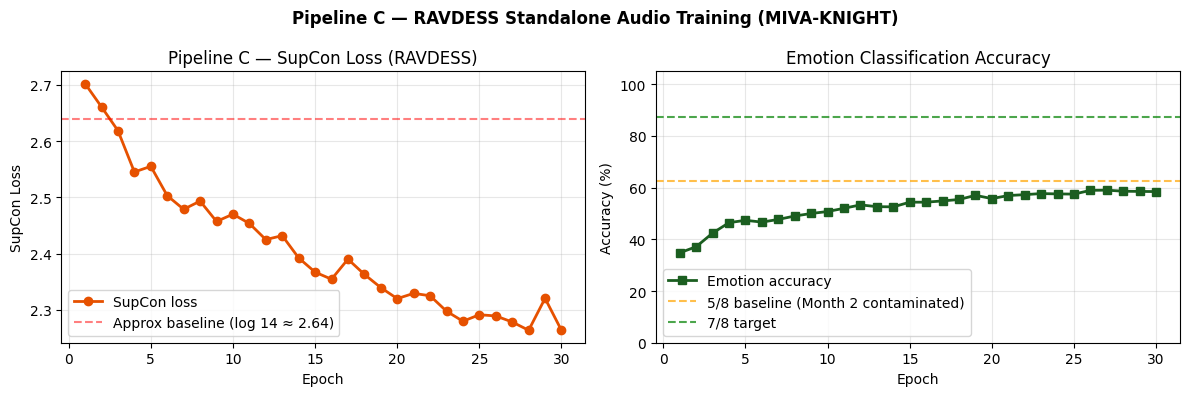

Loss:     2.7019 → 2.2633  (16% reduction)
Accuracy: 34.8% → 59.0%  (best epoch 27)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(all_losses) + 1)

axes[0].plot(ep, all_losses, marker='o', color='#E65100', linewidth=2, label='SupCon loss')
axes[0].axhline(y=np.log(14), color='red', linestyle='--',
                alpha=0.5, label=f'Approx baseline (log 14 ≈ {np.log(14):.2f})')
axes[0].set_title('Pipeline C — SupCon Loss (RAVDESS)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('SupCon Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in all_accs], marker='s',
             color='#1B5E20', linewidth=2, label='Emotion accuracy')
axes[1].axhline(y=62.5, color='orange', linestyle='--',
                alpha=0.7, label='5/8 baseline (Month 2 contaminated)')
axes[1].axhline(y=87.5, color='green', linestyle='--',
                alpha=0.7, label='7/8 target')
axes[1].set_title('Emotion Classification Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([0, 105])
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Pipeline C — RAVDESS Standalone Audio Training (MIVA-KNIGHT)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PIPELINE_C_DIR, 'training_curves_pipelineC.png'), dpi=150)
plt.show()

if all_losses:
    drop = (all_losses[0] - all_losses[-1]) / all_losses[0] * 100
    print(f"Loss:     {all_losses[0]:.4f} \u2192 {all_losses[-1]:.4f}  ({drop:.0f}% reduction)")
    print(f"Accuracy: {all_accs[0]*100:.1f}% \u2192 {max(all_accs)*100:.1f}%  (best epoch {best_epoch})")


## Cell 17: Compute & Save Emotion Centroids

### What are emotion centroids?

For each of the 8 emotions, compute the **mean projected embedding** across all
RAVDESS clips of that emotion. This gives 8 representative 512d vectors —
one per emotion class — that live in the shared embedding space.

### How centroids are used at inference

When a user speaks, MIVA-KNIGHT:
1. Runs Wav2Vec 2.0 on their voice → 768d
2. Runs `AudioProjection` → 512d
3. Computes cosine similarity to all 8 centroids
4. Takes the nearest centroid → detected emotion
5. Injects emotion context into the Groq prompt

This is exactly the pattern from Month 4 Cell 12 — now with properly trained centroids.

### Output: `emotion_centroids.pt`

Shape: `[8, 512]` float32 tensor.
Row order: `[neutral, calm, happy, sad, angry, fearful, disgust, surprised]`
Compatible with `pipeline.py` and `domain_config.py` unchanged.


In [17]:
print("Computing emotion centroids from best AudioProjection weights...")

audio_proj.eval()
emotion_embs = defaultdict(list)

with torch.no_grad():
    for embs_batch, labels_batch in tqdm(audio_loader, desc="Projecting", leave=False):
        proj = audio_proj(embs_batch.to(device)).cpu()
        for emb, label in zip(proj, labels_batch):
            emotion_embs[LABEL_TO_EMOTION[label.item()]].append(emb)

# Build [8, 512] centroid tensor — same order as EMOTIONS_8
centroids_list = []
print("\nCentroid quality check:")
print(f"{'Emotion':<12} {'Samples':>8} {'Norm':>8}")
print("-" * 32)

for emotion in EMOTIONS_8:
    emb_stack = torch.stack(emotion_embs[emotion])   # [N_e, 512]
    centroid  = F.normalize(emb_stack.mean(dim=0), p=2, dim=0)
    centroids_list.append(centroid)
    print(f"  {emotion:<10}  {len(emb_stack):>6}   {centroid.norm().item():.4f}")

centroids_tensor = torch.stack(centroids_list)   # [8, 512]

# Verify no zero centroids
zero_cents = (centroids_tensor.norm(dim=1) < 0.01).sum().item()
print(f"\nShape : {list(centroids_tensor.shape)}")
print(f"Zeros : {zero_cents}/8  {'\u2705' if zero_cents == 0 else '\u26a0\ufe0f  zero centroids detected'}")

# Inter-centroid similarity matrix — emotions should be spread apart
print("\nInter-centroid cosine similarity (lower = better separated):")
sim_mat = torch.mm(centroids_tensor, centroids_tensor.t())
off_diag = sim_mat[~torch.eye(8, dtype=bool)].mean().item()
print(f"  Mean off-diagonal similarity: {off_diag:.4f}  "
      f"({'\u2705 well separated' if off_diag < 0.5 else '\u26a0\ufe0f  emotions still close'})")

# Save
CENTROIDS_PATH = os.path.join(PIPELINE_C_DIR, 'emotion_centroids.pt')
torch.save(centroids_tensor, CENTROIDS_PATH)
print(f"\n\u2713 Saved: {CENTROIDS_PATH}")


Computing emotion centroids from best AudioProjection weights...


Projecting:   0%|          | 0/90 [00:00<?, ?it/s]


Centroid quality check:
Emotion       Samples     Norm
--------------------------------
  neutral         96   1.0000
  calm           192   1.0000
  happy          192   1.0000
  sad            192   1.0000
  angry          192   1.0000
  fearful        192   1.0000
  disgust        192   1.0000
  surprised      192   1.0000

Shape : [8, 512]
Zeros : 0/8  ✅

Inter-centroid cosine similarity (lower = better separated):
  Mean off-diagonal similarity: 0.8879  (⚠️  emotions still close)

✓ Saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineC/emotion_centroids.pt


## Cell 18: Save All Pipeline C Outputs


In [18]:
print("Saving Pipeline C outputs to Google Drive...")

# ── AudioProjection weights ────────────────────────────────────────────────
audio_proj_path = os.path.join(PIPELINE_C_DIR, 'audio_projection.pth')
torch.save({
    'model_state_dict' : audio_proj.state_dict(),
    'wav2vec_dim'      : WAV2VEC_DIM,
    'embed_dim'        : EMBED_DIM,
    'best_epoch'       : best_epoch,
    'best_accuracy'    : best_acc,
    'pipeline'         : 'C-RAVDESS-standalone',
}, audio_proj_path)
print(f"\u2713 audio_projection.pth saved  ({os.path.getsize(audio_proj_path)/1e6:.1f} MB)")

# ── Config ─────────────────────────────────────────────────────────────────
config = {
    'pipeline'         : 'C — RAVDESS Standalone Audio Emotion',
    'replan'           : 'Supervisor Month 5 — 4 separate pipelines',
    'what_changed'     : (
        'RAVDESS trained standalone. No COCO mixing. '
        'wav2vec_dim fixed from 512 to 768. SupCon loss replaces InfoNCE.'
    ),
    'dataset'          : 'RAVDESS (1,440 .wav clips, 8 emotions, 24 actors)',
    'loss'             : 'Supervised Contrastive (SupCon, Khosla et al. 2020)',
    'wav2vec_dim'      : WAV2VEC_DIM,
    'embed_dim'        : EMBED_DIM,
    'wav2vec_frozen'   : True,
    'epochs'           : NUM_EPOCHS,
    'batch_size'       : BATCH_SIZE,
    'learning_rate'    : LEARNING_RATE,
    'temperature'      : TEMPERATURE,
    'best_epoch'       : best_epoch,
    'best_accuracy'    : round(best_acc, 4),
    'final_loss'       : round(all_losses[-1], 6) if all_losses else None,
    'emotions'         : EMOTIONS_8,
    'per_emotion_accuracy': {e: round(a, 4) for e, a in per_emotion_acc.items()},
    'n_emotions_correct'  : sum(1 for a in per_emotion_acc.values() if a >= 0.5),
    'month2_baseline'     : '5/8 emotions (contaminated joint training)',
}
config_path = os.path.join(PIPELINE_C_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"\u2713 config.json saved")

# ── Directory listing ──────────────────────────────────────────────────────
print(f"\n\u2713 All files in {PIPELINE_C_DIR}:")
for fname in sorted(os.listdir(PIPELINE_C_DIR)):
    fpath = os.path.join(PIPELINE_C_DIR, fname)
    print(f"    {fname:<50} {os.path.getsize(fpath)/1e6:6.1f} MB")

print(f"\n\u2713 768d embedding cache: {CACHE_768_FILE}")
print(f"   {os.path.getsize(CACHE_768_FILE)/1e6:.1f} MB  (reuse for future runs)")


Saving Pipeline C outputs to Google Drive...
✓ audio_projection.pth saved  (4.0 MB)
✓ config.json saved

✓ All files in /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineC:
    audio_projection.pth                                  4.0 MB
    checkpoint_pipelineC_latest.pth                      11.9 MB
    config.json                                           0.0 MB
    emotion_centroids.pt                                  0.0 MB
    training_curves_pipelineC.png                         0.1 MB

✓ 768d embedding cache: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/audio_embeddings_cache/ravdess_embeddings_768d.pt
   4.9 MB  (reuse for future runs)


## Cell 19: Update domain_config.py

`domain_config.py` must point to the new Pipeline C audio weights.
This cell prints the exact lines to change — do NOT change any other settings.


In [19]:
print("=" * 60)
print("ACTION REQUIRED: Update domain_config.py")
print("=" * 60)
print()
print("Change these two lines in domain_config.py:")
print()
print("  # OLD (contaminated Month 2 joint weights):")
print("  audio_weights   = '.../miva_knight_month2_rebuilt/audio_projection.pth'")
print("  emotion_centroids = '.../miva_knight_month2_rebuilt/emotion_centroids.pt'")
print()
print("  # NEW (Pipeline C standalone — correct 768d):")
print(f"  audio_weights     = '{audio_proj_path}'")
print(f"  emotion_centroids = '{CENTROIDS_PATH}'")
print()
print("Both GeneralDomain and MedicalDomain use the same AudioProjection")
print("(audio emotion detection is domain-independent).")
print()
print("=" * 60)
print("PIPELINE C COMPLETE")
print("=" * 60)
print(f"  Dataset   : RAVDESS (1,440 clips, 8 emotions)")
print(f"  Loss      : SupCon (standalone, no COCO)")
print(f"  wav2vec   : 768d (fixed from original 512d bug)")
print(f"  Best acc  : {best_acc*100:.1f}% (epoch {best_epoch})")
print(f"  Emotions  : {sum(1 for a in per_emotion_acc.values() if a >= 0.5)}/8 correct")
print(f"  vs Month 2: 5/8 (contaminated joint training)")
print()
print("Next: Pipeline D — CREMA-D audio-visual MER (Month 6)")


ACTION REQUIRED: Update domain_config.py

Change these two lines in domain_config.py:

  # OLD (contaminated Month 2 joint weights):
  audio_weights   = '.../miva_knight_month2_rebuilt/audio_projection.pth'
  emotion_centroids = '.../miva_knight_month2_rebuilt/emotion_centroids.pt'

  # NEW (Pipeline C standalone — correct 768d):
  audio_weights     = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineC/audio_projection.pth'
  emotion_centroids = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineC/emotion_centroids.pt'

Both GeneralDomain and MedicalDomain use the same AudioProjection
(audio emotion detection is domain-independent).

PIPELINE C COMPLETE
  Dataset   : RAVDESS (1,440 clips, 8 emotions)
  Loss      : SupCon (standalone, no COCO)
  wav2vec   : 768d (fixed from original 512d bug)
  Best acc  : 59.0% (epoch 27)
  Emotions  : 6/8 correct
  vs Month 2: 5/8 (contaminated joint training)

Next: Pipeline D